In [1]:
import pandas as pd
import numpy as np
data = {
    "Energy source": ["Solar", "Wind", "Hydropower", "Geothermal", "Biomass", "Nuclear"],
    "Energy Consumption (MWh)": [1200,np.nan, 2900, np.nan, 2500, 3200],
    "Cost (Million $)": [200, 400, np.nan, 150, 250, np.nan]
}
energy_df = pd.DataFrame(data)
print("Original Energy Data with Missing Values:")
print(energy_df)

Original Energy Data with Missing Values:
  Energy source  Energy Consumption (MWh)  Cost (Million $)
0         Solar                    1200.0             200.0
1          Wind                       NaN             400.0
2    Hydropower                    2900.0               NaN
3    Geothermal                       NaN             150.0
4       Biomass                    2500.0             250.0
5       Nuclear                    3200.0               NaN


In [2]:
energy_df.head()

,Energy source,Energy Consumption (MWh),Cost (Million $)
0,Solar,1200.0,200.0
1,Wind,NaN,400.0
2,Hydropower,2900.0,NaN
3,Geothermal,NaN,150.0
4,Biomass,2500.0,250.0


In [3]:
energy_df.tail()

,Energy source,Energy Consumption (MWh),Cost (Million $)
1,Wind,NaN,400.0
2,Hydropower,2900.0,NaN
3,Geothermal,NaN,150.0
4,Biomass,2500.0,250.0
5,Nuclear,3200.0,NaN


In [4]:
energy_df.info

<bound method DataFrame.info of   Energy source  Energy Consumption (MWh)  Cost (Million $)
0         Solar                    1200.0             200.0
1          Wind                       NaN             400.0
2    Hydropower                    2900.0               NaN
3    Geothermal                       NaN             150.0
4       Biomass                    2500.0             250.0
5       Nuclear                    3200.0               NaN>

In [5]:
energy_df.isnull().sum()

Energy source               0
Energy Consumption (MWh)    2
Cost (Million $)            2
dtype: int64

In [6]:
cleaned_df = energy_df.dropna()
print("\nData After Removing Rows with Missing values:")
print(cleaned_df)


Data After Removing Rows with Missing values:
  Energy source  Energy Consumption (MWh)  Cost (Million $)
0         Solar                    1200.0             200.0
4       Biomass                    2500.0             250.0


In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
energy_df["Energy Consumption (MWh)"].fillna(energy_df["Energy Consumption (MWh)"].mean(), inplace=True)
energy_df["Cost (Million $)"].fillna(energy_df["Cost (Million $)"].mean(), inplace=True)
print("\nData After Imputing Missing Values with Mean:")
print(energy_df)


Data After Imputing Missing Values with Mean:
  Energy source  Energy Consumption (MWh)  Cost (Million $)
0         Solar                    1200.0             200.0
1          Wind                    2450.0             400.0
2    Hydropower                    2900.0             250.0
3    Geothermal                    2450.0             150.0
4       Biomass                    2500.0             250.0
5       Nuclear                    3200.0             250.0


In [9]:
#forward fill missing values
forward_filled_df = energy_df.fillna(method="ffill")
print("\ndata after Forward filling:")
print(forward_filled_df)


data after Forward filling:
  Energy source  Energy Consumption (MWh)  Cost (Million $)
0         Solar                    1200.0             200.0
1          Wind                    2450.0             400.0
2    Hydropower                    2900.0             250.0
3    Geothermal                    2450.0             150.0
4       Biomass                    2500.0             250.0
5       Nuclear                    3200.0             250.0


In [10]:
energy_df["Missing Consumption"]=energy_df["Energy Consumption (MWh)"].isna().astype(int)
print("\nData with Missing Values Flagged:")
print(energy_df)


Data with Missing Values Flagged:
  Energy source  Energy Consumption (MWh)  Cost (Million $)  \
0         Solar                    1200.0             200.0   
1          Wind                    2450.0             400.0   
2    Hydropower                    2900.0             250.0   
3    Geothermal                    2450.0             150.0   
4       Biomass                    2500.0             250.0   
5       Nuclear                    3200.0             250.0   

   Missing Consumption  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  
5                    0  


In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
energy_df[["Energy Consumption (MWh)", "Cost (Million $)"]] = scaler.fit_transform(energy_df[["Energy Consumption (MWh)", "Cost (Million $)"]])
print("\nData After Normalization (Min-Max Scaling):")
print(energy_df)


Data After Normalization (Min-Max Scaling):
  Energy source  Energy Consumption (MWh)  Cost (Million $)  \
0         Solar                     0.000               0.2   
1          Wind                     0.625               1.0   
2    Hydropower                     0.850               0.4   
3    Geothermal                     0.625               0.0   
4       Biomass                     0.650               0.4   
5       Nuclear                     1.000               0.4   

   Missing Consumption  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  
5                    0  


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
energy_df[["Energy Consumption (MWh)", "Cost (Million $)"]] = scaler.fit_transform(energy_df[["Energy Consumption (MWh)", "Cost (Million $)"]])
print("\nData After standardization (Z-score Scaling):")
print(energy_df)


Data After standardization (Z-score Scaling):
  Energy source  Energy Consumption (MWh)  Cost (Million $)  \
0         Solar             -2.005893e+00     -6.546537e-01   
1          Wind              3.563181e-16      1.963961e+00   
2    Hydropower              7.221213e-01      1.817029e-16   
3    Geothermal              3.563181e-16     -1.309307e+00   
4       Biomass              8.023570e-02      1.817029e-16   
5       Nuclear              1.203536e+00      1.817029e-16   

   Missing Consumption  
0                    0  
1                    0  
2                    0  
3                    0  
4                    0  
5                    0  


In [13]:
#one-hot encode the 'Energy source' column
energy_encoded_df = pd.get_dummies(energy_df, columns=["Energy source"])
print("\nData After One-Hot Encoding Categorical Variables:")
print(energy_encoded_df)


Data After One-Hot Encoding Categorical Variables:
   Energy Consumption (MWh)  Cost (Million $)  Missing Consumption  \
0             -2.005893e+00     -6.546537e-01                    0   
1              3.563181e-16      1.963961e+00                    0   
2              7.221213e-01      1.817029e-16                    0   
3              3.563181e-16     -1.309307e+00                    0   
4              8.023570e-02      1.817029e-16                    0   
5              1.203536e+00      1.817029e-16                    0   

   Energy source_Biomass  Energy source_Geothermal  Energy source_Hydropower  \
0                  False                     False                     False   
1                  False                     False                     False   
2                  False                     False                      True   
3                  False                      True                     False   
4                   True                     False       

In [14]:
energy_encoded_df["Consumption per $Million"] = energy_encoded_df["Energy Consumption (MWh)"] / energy_encoded_df["Cost (Million $)"]
print("\nData with New Feature (Consumption per $Million):")
print(energy_encoded_df)


Data with New Feature (Consumption per $Million):
   Energy Consumption (MWh)  Cost (Million $)  Missing Consumption  \
0             -2.005893e+00     -6.546537e-01                    0   
1              3.563181e-16      1.963961e+00                    0   
2              7.221213e-01      1.817029e-16                    0   
3              3.563181e-16     -1.309307e+00                    0   
4              8.023570e-02      1.817029e-16                    0   
5              1.203536e+00      1.817029e-16                    0   

   Energy source_Biomass  Energy source_Geothermal  Energy source_Hydropower  \
0                  False                     False                     False   
1                  False                     False                     False   
2                  False                     False                      True   
3                  False                      True                     False   
4                   True                     False        

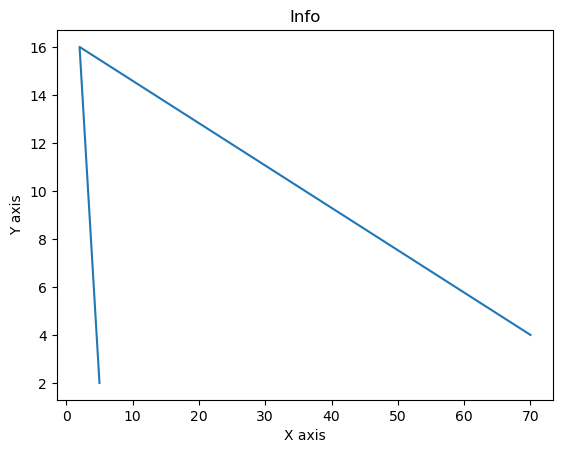

In [15]:
from matplotlib import pyplot as plt
x=[5,2,70]
y=[2,16,4]
plt.plot(x,y)
plt.title('Info')
plt.ylabel('Y axis')
plt.xlabel('X axis')
plt.show()

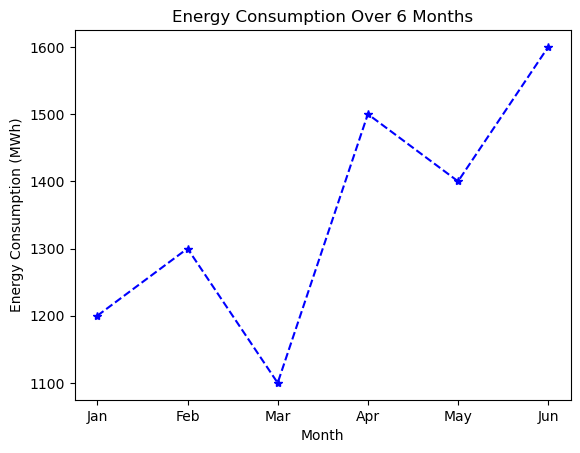

In [16]:
import matplotlib.pyplot as plt
months=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
energy_consumption = [1200, 1300, 1100, 1500, 1400, 1600]
plt.plot(months,energy_consumption, marker='*', color='b', linestyle='--')
plt.title('Energy Consumption Over 6 Months')
plt.xlabel('Month')
plt.ylabel('Energy Consumption (MWh)')
plt.show()

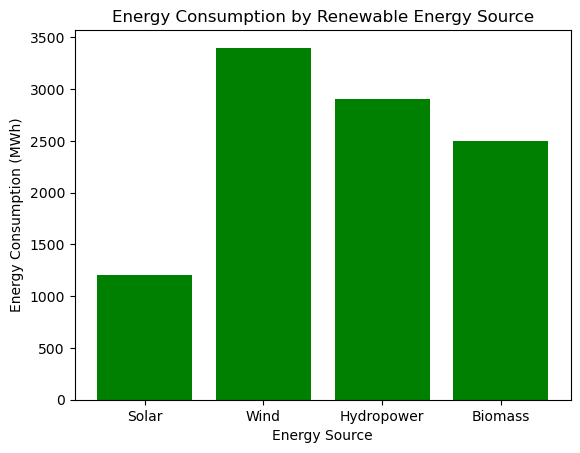

In [17]:
energy_sources = ['Solar','Wind','Hydropower','Biomass']
energy_values = [1200,3400,2900,2500]
plt.bar(energy_sources, energy_values, color='green')
plt.title('Energy Consumption by Renewable Energy Source')
plt.xlabel('Energy Source')
plt.ylabel('Energy Consumption (MWh)')
plt.show()

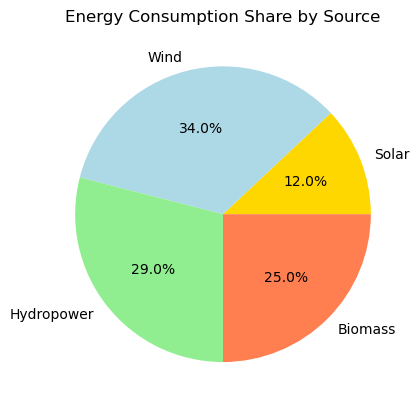

In [18]:
plt.pie(energy_values, labels=energy_sources, autopct='%1.1f%%', colors=['gold','lightblue','lightgreen','coral'])
plt.title('Energy Consumption Share by Source')
plt.show()

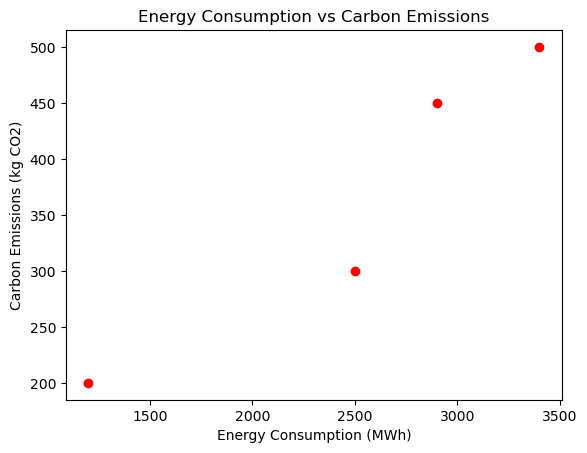

In [19]:
carbon_emissions = [200, 500, 450, 300]
plt.scatter(energy_values, carbon_emissions, color='red')
plt.title('Energy Consumption vs Carbon Emissions')
plt.xlabel('Energy Consumption (MWh)')
plt.ylabel('Carbon Emissions (kg CO2)')
plt.show()

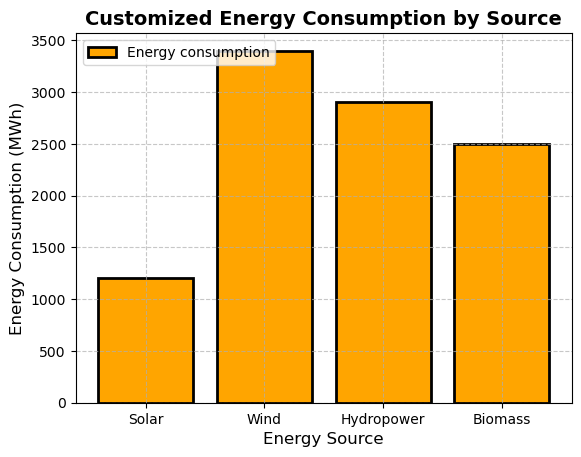

In [20]:
plt.bar(energy_sources, energy_values, color='orange', edgecolor='black', linewidth=2)
plt.title('Customized Energy Consumption by Source', fontsize=14, fontweight='bold')
plt.xlabel('Energy Source', fontsize=12)
plt.ylabel('Energy Consumption (MWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(['Energy consumption'], loc='upper left')
plt.show()



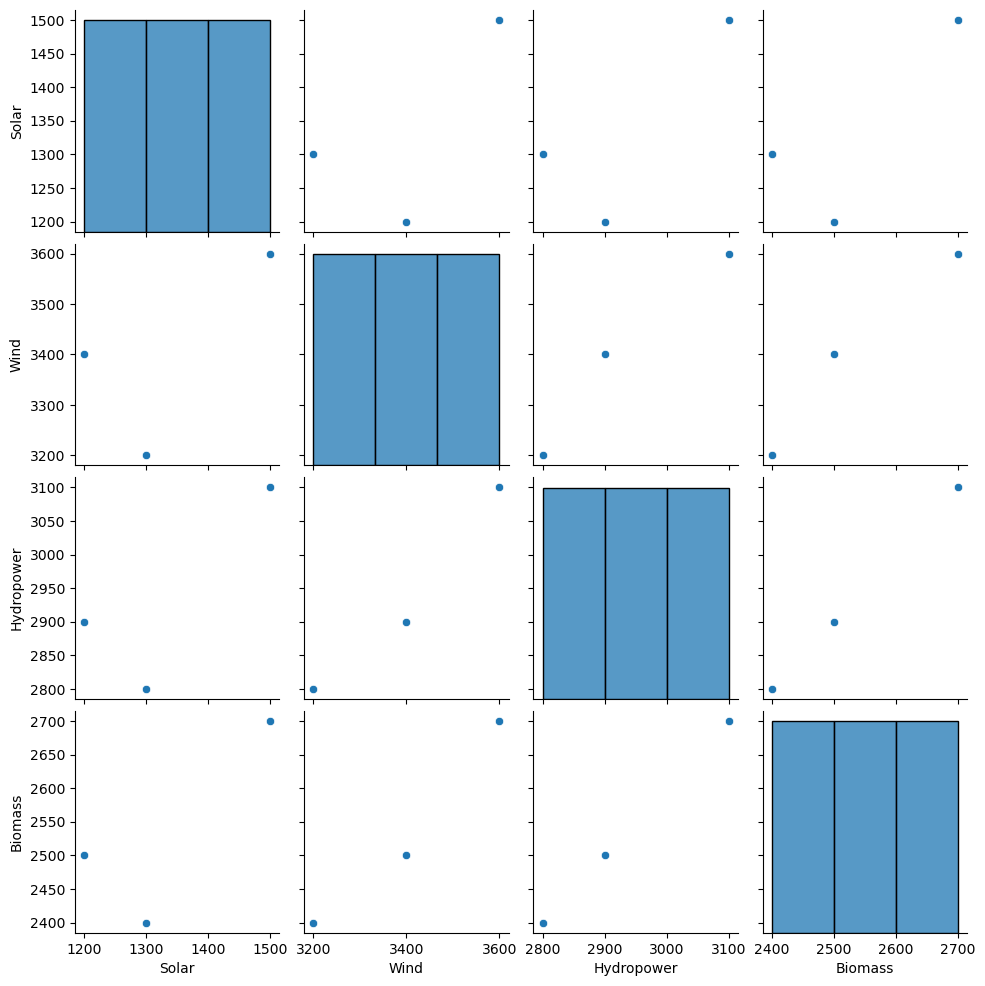

In [21]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
# Creating a DataFrame for pair plot
data={
    "Solar": [1200, 1500, 1300],
    "Wind": [3400, 3600, 3200],
    "Hydropower": [2900, 3100, 2800],
    "Biomass": [2500, 2700, 2400]
}
df = pd.DataFrame(data)
#f Create a pair plot

sns.pairplot(df)


plt.show()


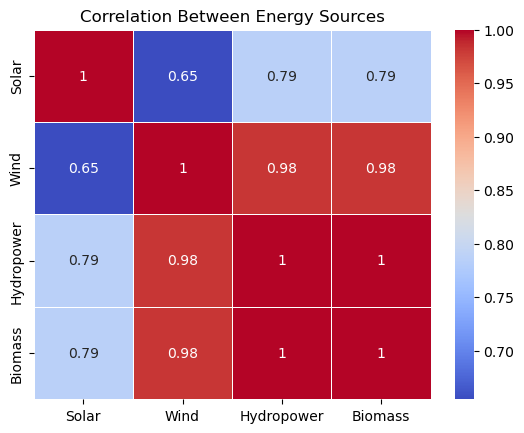

In [44]:
#create a heat map to show the correlation matrix
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Energy Sources')
plt.show()

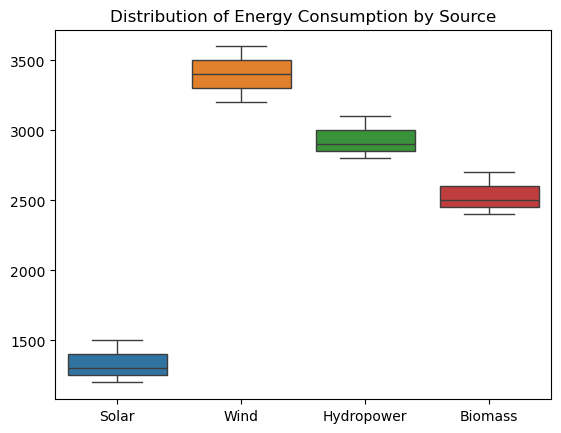

In [46]:
#create a box plot
sns.boxplot(data=df)
plt.title('Distribution of Energy Consumption by Source')
plt.show()

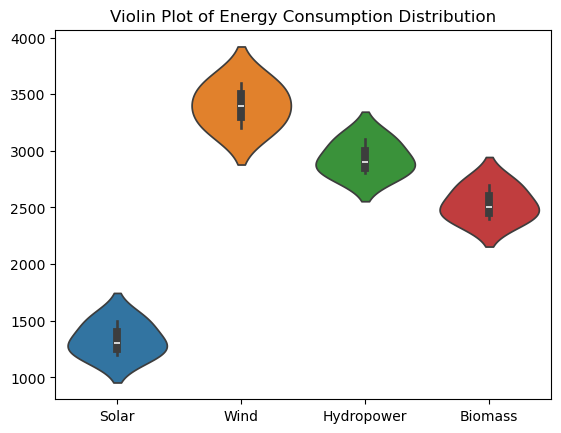

In [48]:
#create a violin plot
sns.violinplot(data=df)
plt.title('Violin Plot of Energy Consumption Distribution')
plt.show()

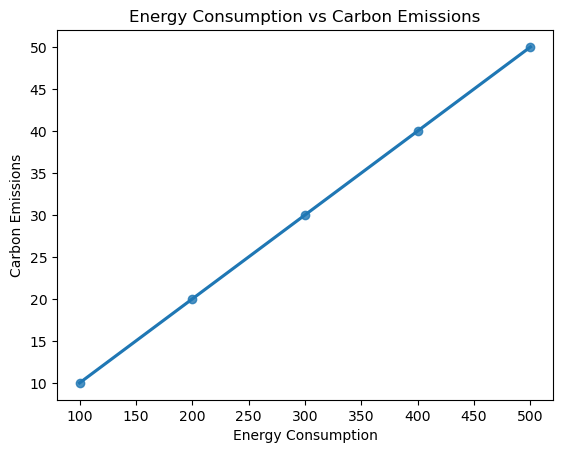

In [50]:
energy_values=[100,200,300,400,500]
carbon_emissions=[10,20,30,40,50]
df_reg=pd.DataFrame({
    'Energy Consumption': energy_values,
    'Carbon Emissions': carbon_emissions
})
#create a regression plot
sns.regplot(x='Energy Consumption', y='Carbon Emissions', data=df_reg)
plt.title('Energy Consumption vs Carbon Emissions')
plt.xlabel('Energy Consumption')
plt.ylabel('Carbon Emissions')
plt.show()

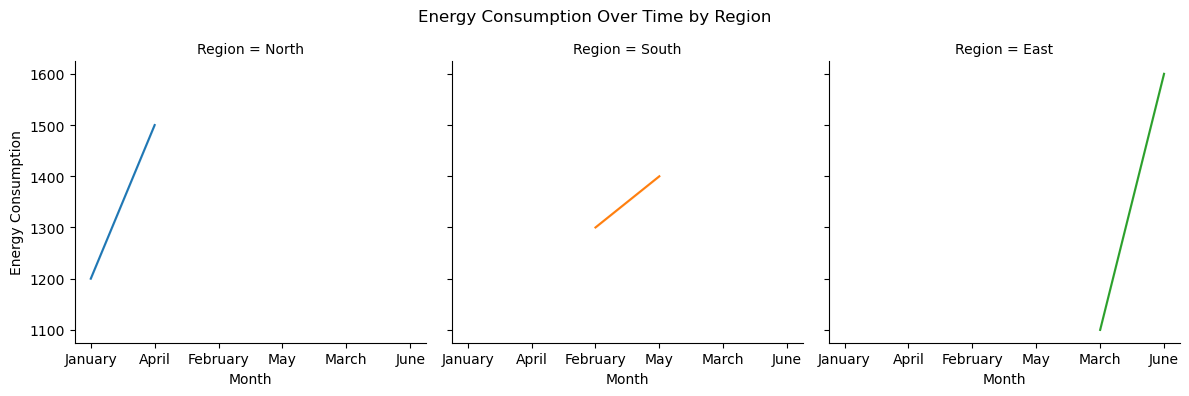

In [54]:
months=['January', 'February', 'March', 'April', 'May', 'June']
df_facet=pd.DataFrame({
    'Month': months * 3,
    'Energy Consumption': [1200,1300,1100,1500,1400,1600] * 3,
    'Region': ['North', 'South', 'East'] * 6
})
#create a facetgrid plot
g=sns.FacetGrid(df_facet, col='Region', hue='Region', height=4, aspect=1)
g.map(sns.lineplot, 'Month', 'Energy Consumption')
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Energy Consumption Over Time by Region')
plt.show()